# Same-coarse-channel voltage drift walkthrough

This notebook follows the existing voltage SNR examples more closely, but uses the native `setigen.voltage.reduce_raw(...)` reducer instead of `rawspec`:

- use `setigen.voltage.get_level()` to set target raw-voltage signal strengths
- place both tones on exact fine-channel centers inside the flat middle of one coarse channel
- record a longer RAW sequence and reduce only that coarse channel to a `.fil` product
- use 11 Hz-class fine channelization so the injected drifts and dedrifted spectra are easier to inspect
- open the reduced filterbank with `blimpy.Waterfall`, convert to a `Frame`, then use `setigen.dedrift()` and `setigen.spectrum(..., normalize=True)`


In [18]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from pathlib import Path

import blimpy as bl
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

import setigen as stg

output_dir = Path.cwd() / "generated"
output_dir.mkdir(parents=True, exist_ok=True)
output_dir


PosixPath('/Users/bryanbrzycki/Code/seti/setigen_development/stg-79_voltage_centered_snr_drift/generated')

In [19]:
noise_seed = 123

sample_rate = 3e9 * u.Hz
num_taps = 8
num_branches = 1024
num_chans = 1
num_pols = 2

fftlength = 262144 // 4
int_factor = 1
tchans_per_block = 8
num_blocks_to_record = 8

total_tchans = tchans_per_block * num_blocks_to_record
target_snrs = {
    "SNR 25": 25,
    "SNR 50": 50,
}
local_bins = {
    "SNR 25": fftlength // 2 - 48,
    "SNR 50": fftlength // 2 + 48,
}
total_pixel_drift = {
    "SNR 25": -8.0,
    "SNR 50": 12.0,
}
window_half_width_hz = 1_500.0
max_working_set_mib = 1024

antenna = stg.voltage.Antenna(sample_rate=sample_rate,
                              fch1=6000e6 * u.Hz,
                              ascending=True,
                              num_pols=num_pols,
                              seed=noise_seed)

block_size = stg.voltage.get_block_size(num_antennas=1,
                                        tchans_per_block=tchans_per_block,
                                        num_bits=8,
                                        num_pols=num_pols,
                                        num_branches=num_branches,
                                        num_chans=num_chans,
                                        fftlength=fftlength,
                                        int_factor=int_factor)

digitizer = stg.voltage.RealQuantizer(target_fwhm=32, num_bits=8)
filterbank = stg.voltage.PolyphaseFilterbank(num_taps=num_taps,
                                             num_branches=num_branches)
requantizer = stg.voltage.ComplexQuantizer(target_fwhm=32, num_bits=8)

rvb = stg.voltage.RawVoltageBackend(antenna,
                                    digitizer=digitizer,
                                    filterbank=filterbank,
                                    requantizer=requantizer,
                                    start_chan=0,
                                    num_chans=num_chans,
                                    block_size=block_size,
                                    blocks_per_file=16,
                                    num_subblocks=10,
                                    max_working_set_bytes=max_working_set_mib * 1024**2)

fine_bw_hz = rvb.chan_bw / fftlength
frame_df = fine_bw_hz * u.Hz
frame_dt = rvb.tbin * fftlength * int_factor * u.s
unit_drift_rate_hz_per_s = stg.voltage.get_unit_drift_rate(rvb,
                                                           fftlength=fftlength,
                                                           int_factor=int_factor)

for stream in antenna.streams:
    stream.add_noise(v_mean=0, v_std=1)

coarse_center_hz = rvb.fch1
signal_frequencies_hz = {}
signal_drift_rates_hz_per_s = {}
signal_levels = {}

for name, snr in target_snrs.items():
    signal_frequencies_hz[name] = coarse_center_hz + (local_bins[name] - fftlength / 2) * fine_bw_hz
    signal_drift_rates_hz_per_s[name] = total_pixel_drift[name] * unit_drift_rate_hz_per_s / total_tchans

    analytic_level = stg.voltage.get_level(snr=snr,
                                           raw_voltage_backend=rvb,
                                           fftlength=fftlength,
                                           num_blocks=num_blocks_to_record,
                                           length_mode="num_blocks")
    leakage_factor = stg.voltage.get_leakage_factor(signal_frequencies_hz[name], rvb, fftlength)
    signal_levels[name] = antenna.x.get_total_noise_std() * leakage_factor * analytic_level

phases = {
    "SNR 25": (0, np.pi / 4),
    "SNR 50": (np.pi / 3, np.pi / 2),
}
for name in target_snrs:
    phase_x, phase_y = phases[name]
    antenna.x.add_constant_signal(f_start=signal_frequencies_hz[name] * u.Hz,
                                  drift_rate=signal_drift_rates_hz_per_s[name] * u.Hz / u.s,
                                  level=signal_levels[name],
                                  phase=phase_x)
    antenna.y.add_constant_signal(f_start=signal_frequencies_hz[name] * u.Hz,
                                  drift_rate=signal_drift_rates_hz_per_s[name] * u.Hz / u.s,
                                  level=signal_levels[name],
                                  phase=phase_y)

summary = {
    "block_size_mib": block_size / 1024**2,
    "fine_resolution_hz": fine_bw_hz,
    "time_resolution_s": frame_dt.to_value(u.s),
    "signal_levels": signal_levels,
    "signal_frequencies_hz": signal_frequencies_hz,
    "signal_drift_rates_hz_per_s": signal_drift_rates_hz_per_s,
}
summary


{'block_size_mib': 2.0,
 'fine_resolution_hz': np.float64(44.70348358154297),
 'time_resolution_s': np.float64(0.022369621333333332),
 'signal_levels': {'SNR 25': np.float64(0.000362917210389014),
  'SNR 50': np.float64(0.0005132424409507535)},
 'signal_frequencies_hz': {'SNR 25': np.float64(5999997854.232788),
  'SNR 50': np.float64(6000002145.767212)},
 'signal_drift_rates_hz_per_s': {'SNR 25': np.float64(-249.80018054066022),
  'SNR 50': np.float64(374.70027081099033)}}

## Inspect raw voltage samples

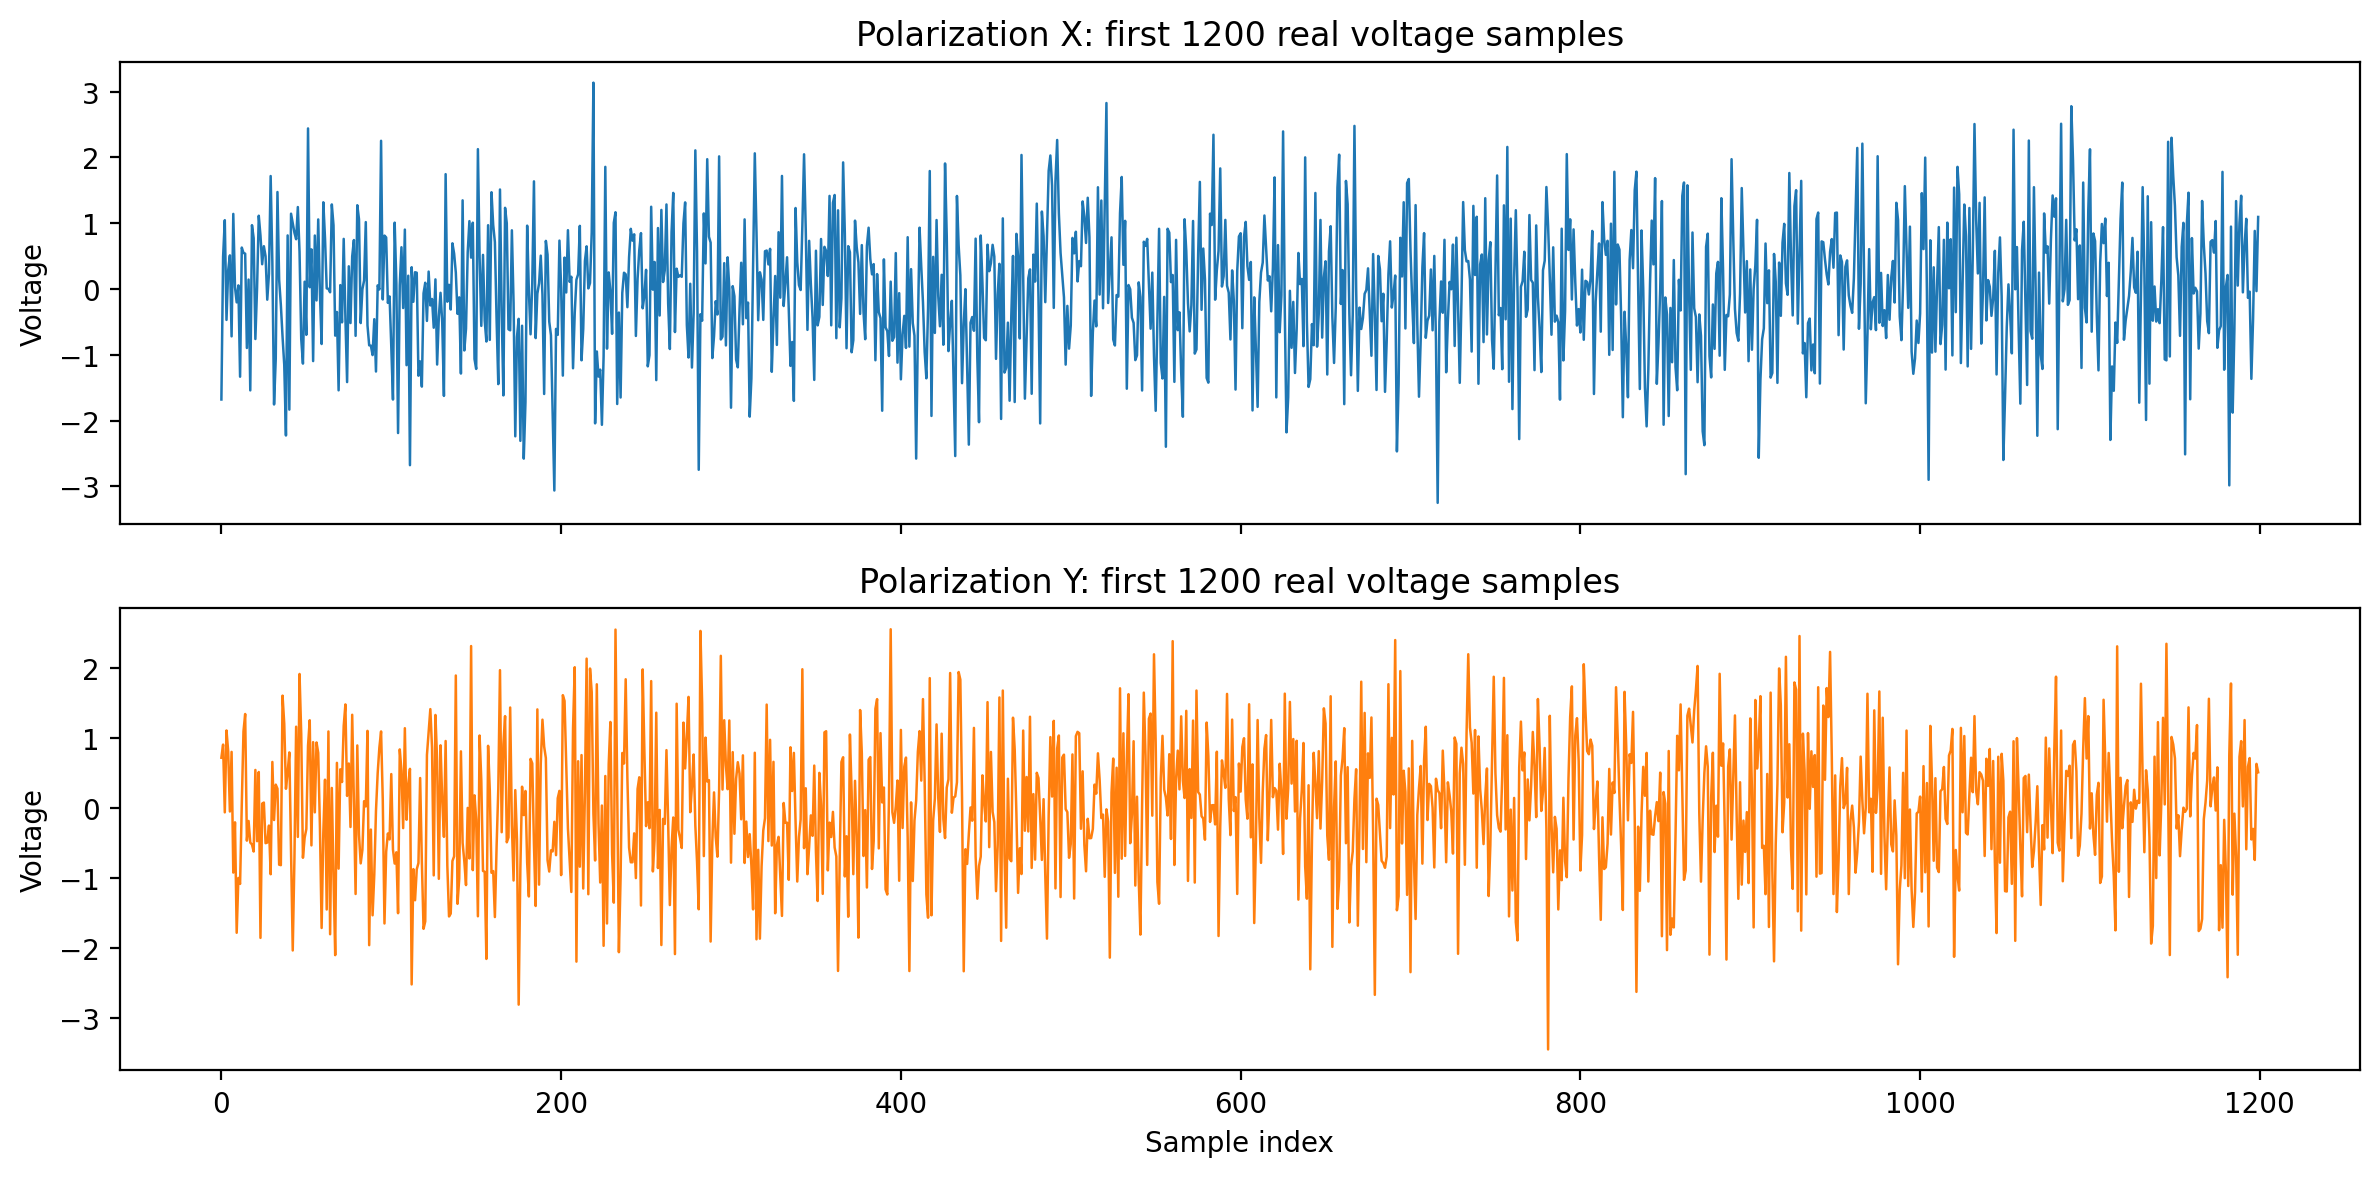

In [20]:
num_preview_samples = 4096
x_preview = antenna.x.get_samples(num_preview_samples)
y_preview = antenna.y.get_samples(num_preview_samples)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(x_preview[:1200], lw=0.9)
axes[0].set_title("Polarization X: first 1200 real voltage samples")
axes[0].set_ylabel("Voltage")

axes[1].plot(y_preview[:1200], lw=0.9, color="tab:orange")
axes[1].set_title("Polarization Y: first 1200 real voltage samples")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Voltage")

plt.tight_layout()
plt.show()


## Record a longer RAW sequence and reduce one coarse channel to `.fil`

This mirrors the original voltage SNR notebook pattern more closely: record RAW, reduce to a filterbank product, then inspect a narrow slice around the injected lines.

In [21]:
raw_stem = output_dir / "voltage_same_channel_snr_11hz_long"
reduced_fil = output_dir / "voltage_same_channel_snr_11hz_long.fil"

rvb.record(output_file_stem=raw_stem,
           num_blocks=num_blocks_to_record,
           length_mode="num_blocks",
           header_dict={"HELLO": "voltage_same_channel_snr_11hz_long", "TELESCOP": "GBT"},
           verbose=True)

Blocks:   0%|          | 0/8 [00:00<?, ?it/s]

Creating block 0...


                                             
Blocks:   0%|          | 0/8 [00:00<?, ?it/s]    

Creating subblock 0...


                                             
Blocks:   0%|          | 0/8 [00:03<?, ?it/s]            

...

Creating subblock 14...


                                                     
Blocks:  88%|████████▊ | 7/8 [07:15<00:54, 54.79s/it]     

Creating subblock 15...


Blocks: 100%|██████████| 8/8 [07:19<00:00, 54.92s/it]

File 0, block 7 recorded!


In [22]:

reduction_spec = stg.voltage.RawReductionSpec(fftlength=fftlength,
                                              integration_factor=int_factor,
                                              pol_mode=stg.voltage.PolarizationMode.TOTAL_POWER,
                                              output_format="fil")

stg.voltage.reduce_raw(raw_stem,
                       reduced_fil,
                       reduction_spec,
                       overwrite=True)

line_pair_center_hz = np.mean(list(signal_frequencies_hz.values()))
window_start_mhz = (line_pair_center_hz - window_half_width_hz) / 1e6
window_stop_mhz = (line_pair_center_hz + window_half_width_hz) / 1e6

wf = bl.Waterfall(str(reduced_fil),
                  f_start=window_start_mhz,
                  f_stop=window_stop_mhz)
narrow_frame = stg.Frame(waterfall=wf)
narrow_db = 10 * np.log10(narrow_frame.data + 1e-12)

freq_offsets_hz = narrow_frame.fs - line_pair_center_hz
narrow_db.shape, narrow_frame.df, narrow_frame.dt


((64, 68), np.float64(44.70348358154297), 0.02236962133333331)

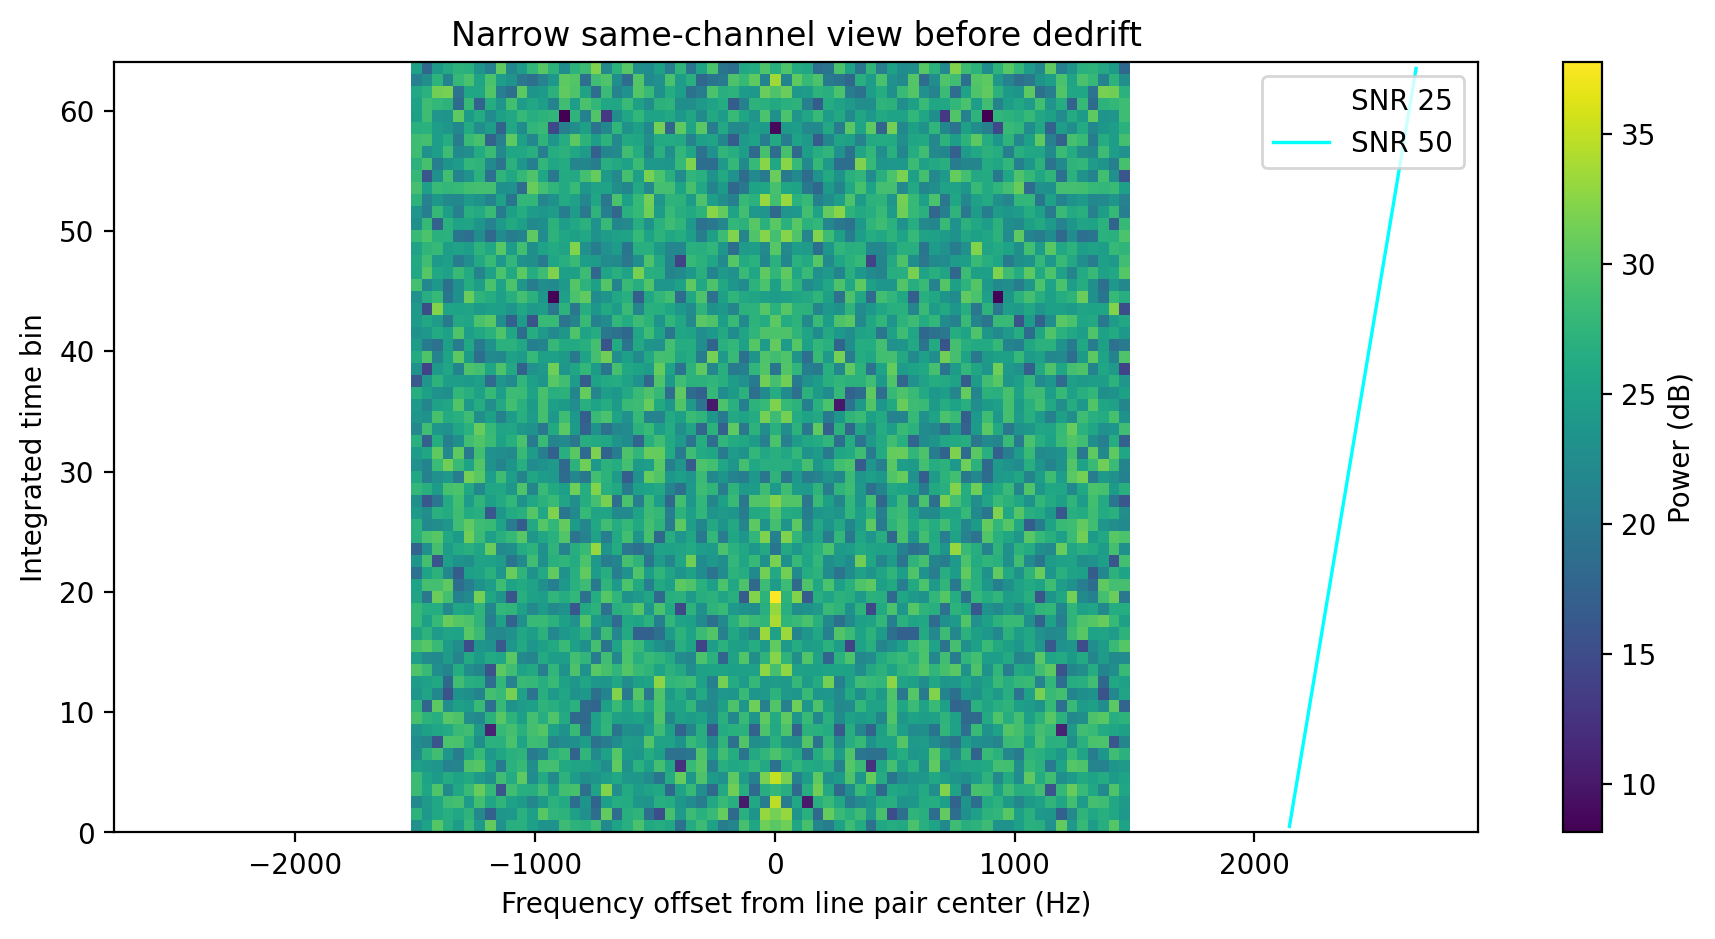

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))

extent = [freq_offsets_hz[0], freq_offsets_hz[-1], 0, narrow_db.shape[0]]
im = ax.imshow(narrow_db,
               aspect="auto",
               origin="lower",
               interpolation="nearest",
               extent=extent)
fig.colorbar(im, ax=ax, label="Power (dB)")
ax.set_title("Narrow same-channel view before dedrift")
ax.set_xlabel("Frequency offset from line pair center (Hz)")
ax.set_ylabel("Integrated time bin")

rows = np.arange(narrow_db.shape[0])
colors = {"SNR 25": "white", "SNR 50": "cyan"}
for name in target_snrs:
    track_offsets_hz = signal_frequencies_hz[name] + rows * narrow_frame.dt * signal_drift_rates_hz_per_s[name] - line_pair_center_hz
    ax.plot(track_offsets_hz, rows + 0.5, color=colors[name], lw=1.2, label=name)

ax.legend(loc="upper right")
plt.show()


## Dedrift each line and form normalized spectra

This uses `setigen.dedrift()` and `setigen.spectrum(..., normalize=True)` on the narrow reduced `Frame`.

In [24]:
dedrifted_frames = {}
dedrifted_spectra = {}

for name in target_snrs:
    drift_rate = signal_drift_rates_hz_per_s[name]
    dd_frame = stg.dedrift(narrow_frame, drift_rate=drift_rate)
    dd_spectrum = stg.spectrum(dd_frame, mode="sum", normalize=True)

    dedrifted_frames[name] = dd_frame
    dedrifted_spectra[name] = dd_spectrum

[(name, dedrifted_frames[name].data.shape, dedrifted_spectra[name].data.shape) for name in target_snrs]


[('SNR 25', (64, 60), (1, 60)), ('SNR 50', (64, 56), (1, 56))]

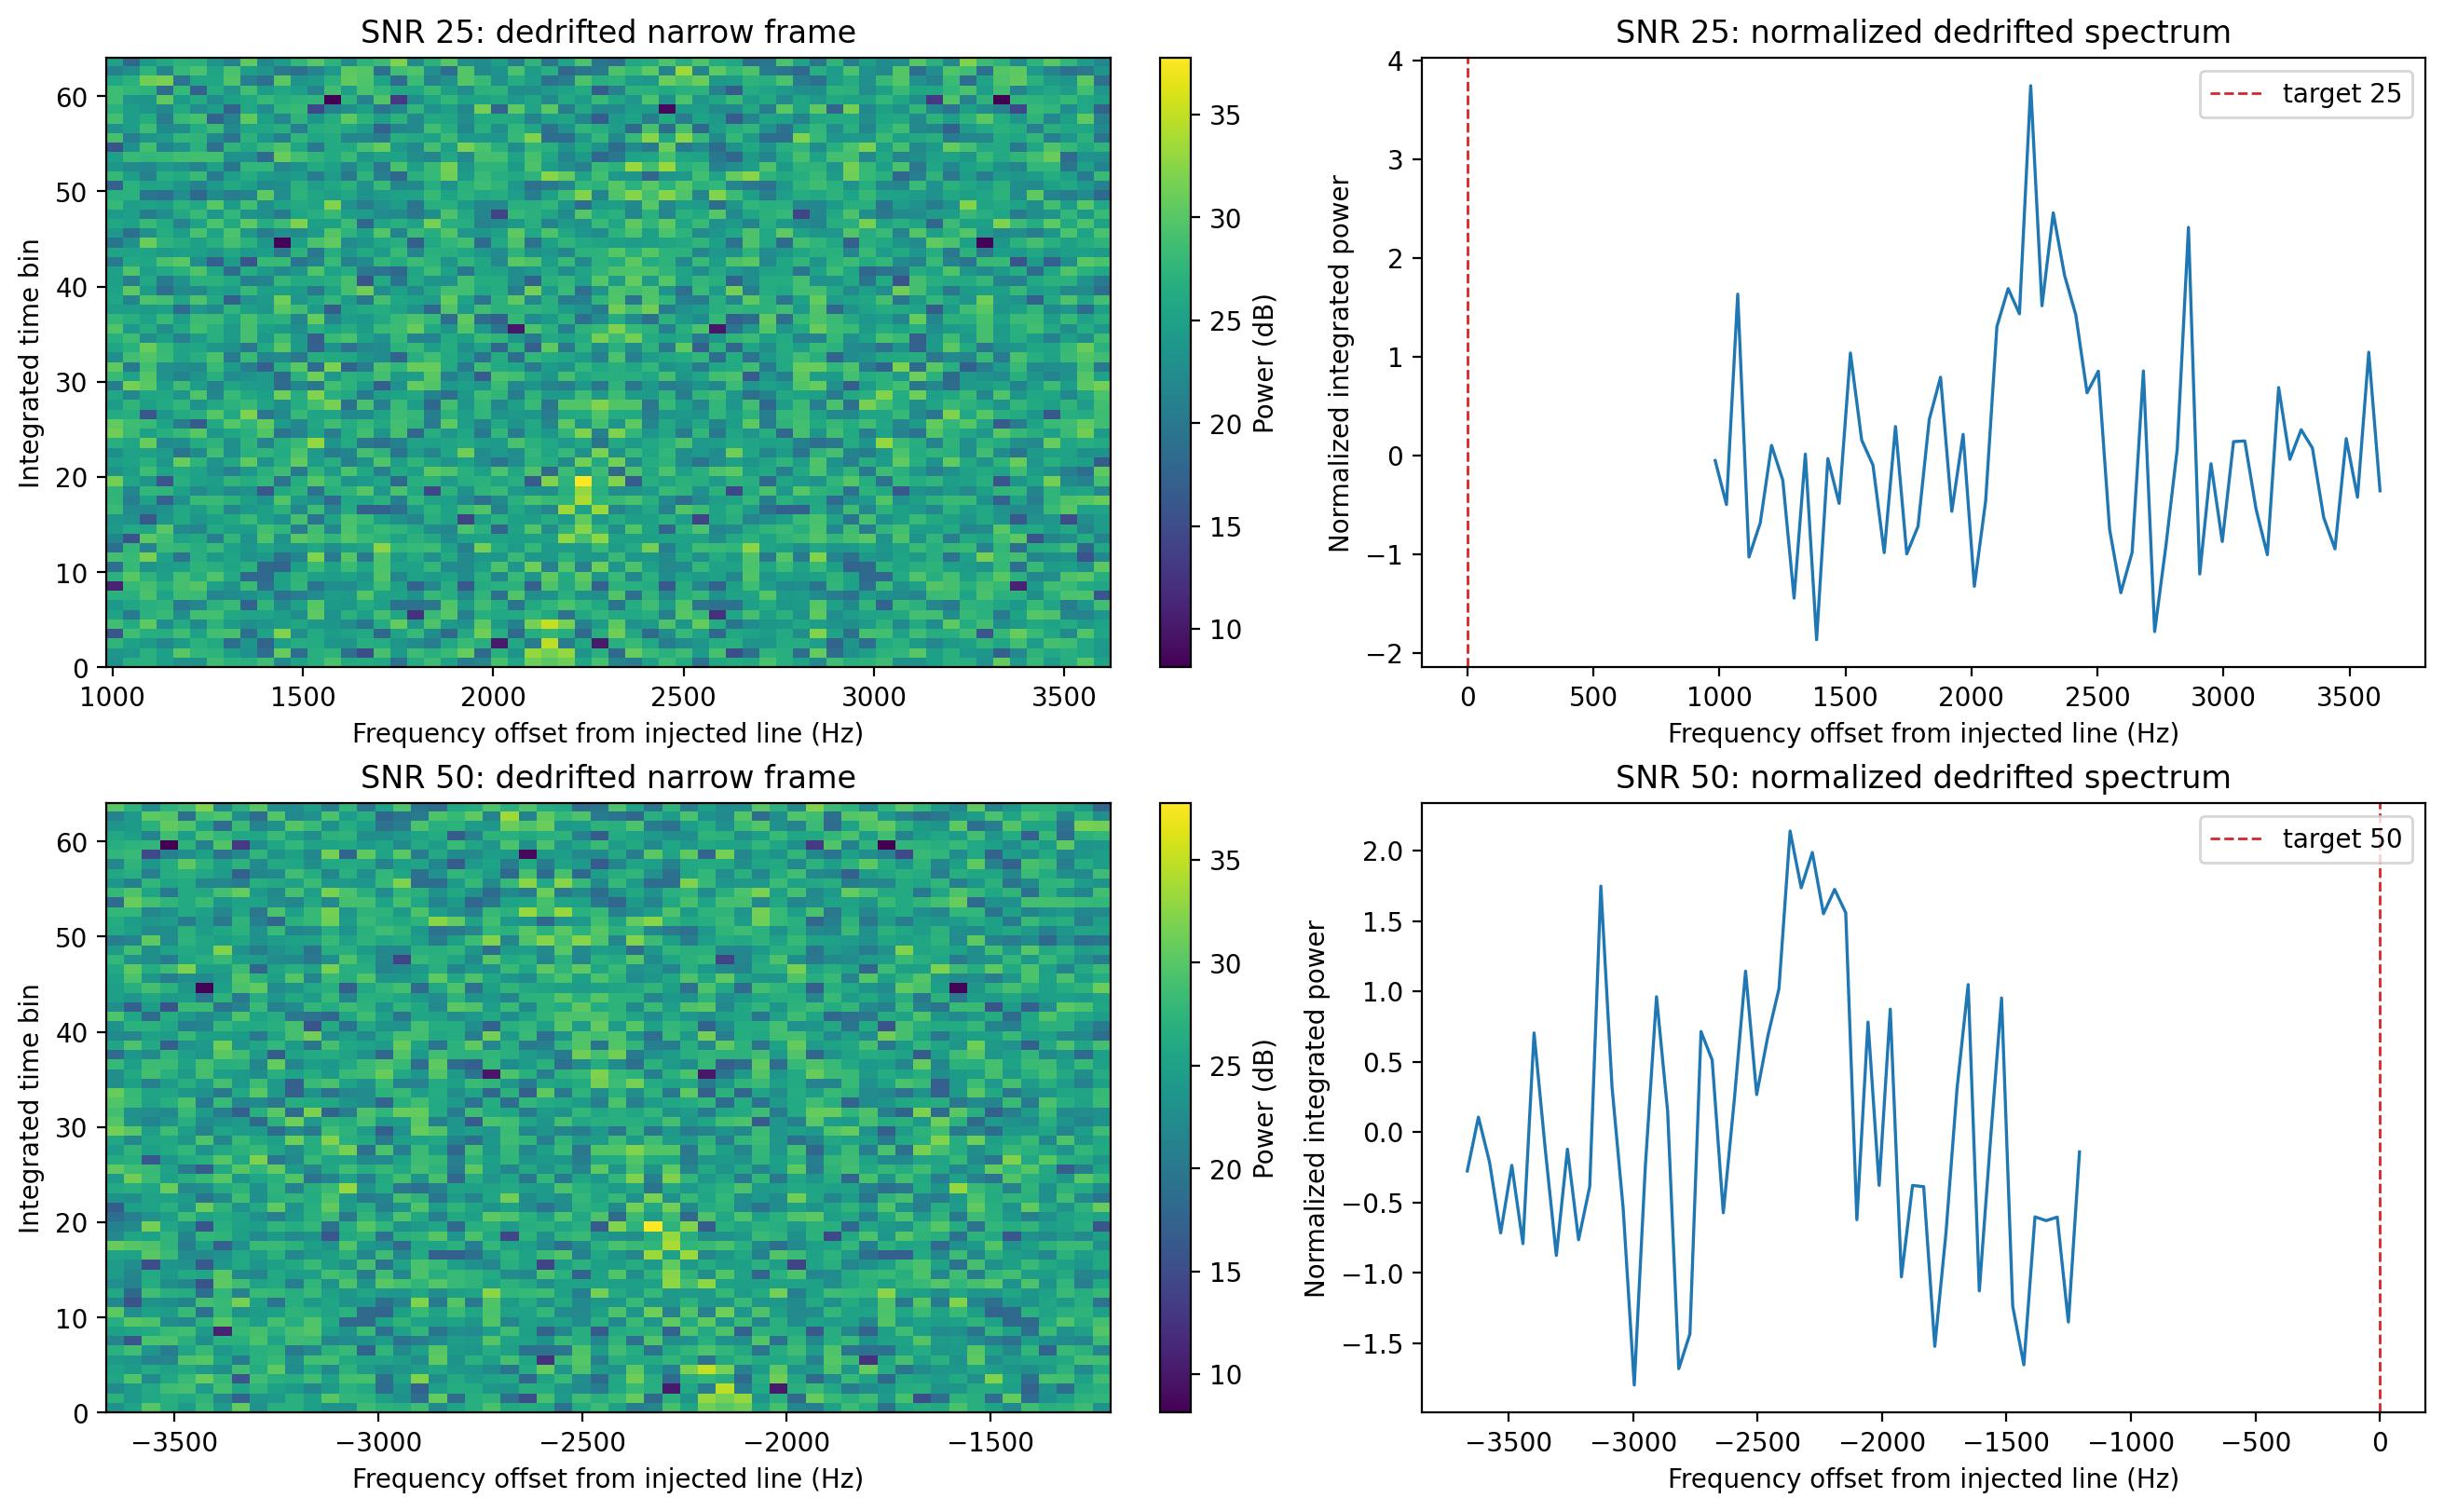

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

plot_order = ["SNR 25", "SNR 50"]
for row, name in enumerate(plot_order):
    dd_frame = dedrifted_frames[name]
    dd_spec = dedrifted_spectra[name]

    freq_offsets_dd_hz = dd_frame.fs - signal_frequencies_hz[name]
    dd_db = 10 * np.log10(dd_frame.data + 1e-12)
    extent = [freq_offsets_dd_hz[0], freq_offsets_dd_hz[-1], 0, dd_db.shape[0]]

    im = axes[row, 0].imshow(dd_db,
                             aspect="auto",
                             origin="lower",
                             interpolation="nearest",
                             extent=extent)
    axes[row, 0].set_title(f"{name}: dedrifted narrow frame")
    axes[row, 0].set_xlabel("Frequency offset from injected line (Hz)")
    axes[row, 0].set_ylabel("Integrated time bin")
    fig.colorbar(im, ax=axes[row, 0], label="Power (dB)")

    spec_offsets_hz = dd_spec.fs - signal_frequencies_hz[name]
    spec_values = dd_spec.array()
    axes[row, 1].plot(spec_offsets_hz, spec_values, lw=1.2)
    axes[row, 1].axvline(0.0, color="tab:red", linestyle="--", lw=1.0, label=f"target {target_snrs[name]}")
    axes[row, 1].set_title(f"{name}: normalized dedrifted spectrum")
    axes[row, 1].set_xlabel("Frequency offset from injected line (Hz)")
    axes[row, 1].set_ylabel("Normalized integrated power")
    axes[row, 1].legend(loc="upper right")

plt.show()


## Notes

- The signal levels are set with `setigen.voltage.get_level()` and multiplied by `get_leakage_factor()` exactly as in the repo SNR examples.
- This version records a longer RAW sequence, reduces only one coarse channel to `.fil`, and then opens that file with `blimpy.Waterfall`, matching the original notebook workflow more closely.
- With `fftlength = 262144`, the fine-channel resolution is about 11.18 Hz for this backend setup.
- The normalized peak height in the final spectrum is not expected to equal 25 or 50 exactly; the point here is that the injection is parameterized by those target SNR settings and remains visible after reduction and dedrifting.
